In [1]:
import sqlite3
import pandas as pd
import numpy as np
import os
from datetime import datetime, date
import matplotlib.pyplot as plt

In [2]:
os.getcwd()

'C:\\Users\\Tom\\Documents\\Project working directory\\Coursework\\Python files'

In [10]:
os.chdir('~\\Project working directory\\Coursework\\Python files')

FileNotFoundError: [WinError 3] The system cannot find the path specified: '~\\Project working directory\\Coursework\\Python files'

# Creating Database

In [11]:
try:
    os.remove('../Python files/py_airline2.db')
except OSError:
    pass

conn = sqlite3.connect('../Python files/py_+airline2.db')

# Creating table arrived using airline data 2001 & 2002

In [12]:
planes = pd.read_csv("../dataverse_files/plane-data.csv")
planes.to_sql('planes', con = conn, index = False)

ValueError: Table 'planes' already exists.

In [13]:
c = conn.cursor()

In [14]:
c.execute('''
CREATE TABLE arrived (
  Year int,
  Month int,
  DayofMonth int,
  DayOfWeek int,
  DepTime  int,
  CRSDepTime int,
  ArrTime int,
  CRSArrTime int,
  UniqueCarrier varchar(5),
  FlightNum int,
  TailNum varchar(8),
  ActualElapsedTime int,
  CRSElapsedTime int,
  AirTime int,
  ArrDelay int,
  DepDelay int,
  Origin varchar(3),
  Dest varchar(3),
  Distance int,
  TaxiIn int,
  TaxiOut int,
  Cancelled int,
  CancellationCode varchar(1),
  Diverted varchar(1),
  CarrierDelay int,
  WeatherDelay int,
  NASDelay int,
  SecurityDelay int,
  LateAircraftDelay int
)
''')

conn.commit()

OperationalError: table arrived already exists

In [50]:
for year in range(2001, 2002):
    print('Processing: ', year)
    arrived1 = pd.read_csv("../Python files/"+str(year)+".csv.bz2", encoding='latin-1')    
    arrived1.to_sql('arrived1', con = conn, if_exists = 'append', index = False)
for year in range(2002, 2003):
    print('Processing: ', year)
    arrived2 = pd.read_csv("../Python files/"+str(year)+".csv.bz2", encoding='latin-1')    
    arrived2.to_sql('arrived2', con = conn, if_exists = 'append', index = False)
conn.commit()

Processing:  2001
Processing:  2002


# Replace all NA with zero, also check if there are missing values

In [67]:
#Cleaning data
arrived1.fillna(value = 0,
          inplace = True)
arrived2.fillna(value = 0,
          inplace = True)

In [79]:
df1 = c.execute('''
SELECT issue_date AS Age, arrived1.ArrDelay as Delay
 FROM planes JOIN arrived1 USING(TailNum)
 WHERE ArrDelay >0
 GROUP BY Age
 ORDER BY Delay DESC
             ''').fetchall()
df2 = c.execute('''
SELECT issue_date AS Age, arrived2.ArrDelay as Delay
 FROM planes JOIN arrived2 USING(TailNum)
 WHERE ArrDelay >0
 GROUP BY Age
 ORDER BY Delay DESC
             ''').fetchall()
dt1 = pd.DataFrame(df1) 
dt2 = pd.DataFrame(df2)
dt3 = pd.concat([dt1, dt2])
dt3.columns = ['Age','Delay']
df3 = dt3.mask(dt3.astype(object).eq('None')).dropna() #Clean data and drop NAs

# Convert dataframe to Age in numbers

In [90]:
def dob(born):
    born = datetime.strptime(born, "%m/%d/%Y").date()
    today = date.today()
    return today.year - born.year - ((today.month, 
                                      today.day) < (born.month, 
                                                    born.day))
df3['Age'] = df3['Age'].apply(dob)

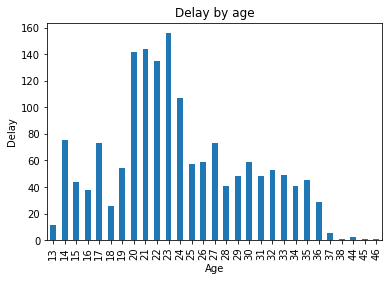

In [106]:
df4 = df3.sort_values(by='Age', ascending=True)
ax = df4.groupby('Age').size().plot(kind='bar',
                                title='Delay by age', 
                                xlabel="Age", 
                                ylabel="Delay")
plt.show()

In [108]:
pd.set_option('display.max_columns', 2000)
dt4 = np.transpose(df4)
dt4

,970,418,228,1322,859,67,502,73,388,215,24,1032,277,830,824,817,1122,801,304,309,795,1274,318,1146,787,1282,332,93,776,1290,360,1299,736,1303,275,267,1249,1149,1060,1022,1192,93,1194,996,118,175,126,127,1203,1207,160,150,953,151,1230,182,199,910,20,898,224,42,208,300,29,434,447,448,461,691,641,694,1315,623,496,612,584,1352,608,680,565,540,1359,1360,716,535,257,216,888,209,1148,204,1150,631,912,920,1340,583,573,147,1167,161,1172,442,1199,1198,172,173,607,606,587,70,969,966,1143,435,409,700,406,319,737,324,412,316,75,773,731,385,414,73,989,756,976,356,144,974,179,79,748,75,1355,1356,51,44,735,6,549,1117,719,1145,1298,967,1288,1279,656,854,883,424,785,310,1333,420,911,648,391,930,1339,927,667,1039,885,1048,946,457,401,40,38,857,1069,1132,569,336,308,816,1,244,798,264,724,686,395,683,556,11,982,738,760,129,180,503,821,758,392,192,194,750,122,692,69,117,749,1001,526,92,88,774,83,702,626,213,175,1028,981,222,1366,1310,1245,1319,1263,1284,1161,169,1316,1358,1300,1269,1247,1243,1341,1278,137,863,12,1351,1239,1346,72,1110,831,636,640,988,87,1005,677,814,179,651,1184,1237,77,219,335,285,1357,212,765,867,430,1168,1169,1050,45,265,991,1171,717,389,272,739,113,757,999,85,89,815,313,311,705,369,233,1321,932,1224,1134,1128,551,545,544,570,537,1114,530,148,1107,588,900,1097,463,810,870,228,458,650,1330,1071,475,226,21,806,1154,1240,131,813,211,147,244,184,858,114,1258,915,191,289,853,866,227,913,139,278,848,201,261,136,887,903,1259,240,207,868,120,861,729,800,669,462,469,470,31,474,627,622,489,613,1342,610,600,674,16,582,527,534,8,539,5,561,560,552,553,554,555,1361,586,112,678,45,110,109,796,793,789,97,339,342,771,348,361,81,170,43,725,723,721,65,1307,394,718,399,1309,405,1312,50,423,426,70,940,226,74,1077,1157,25,146,1075,1159,1213,980,985,987,1009,1197,55,61,1079,66,191,177,1195,150,180,1017,1016,1000,86,181,1014,105,103,1011,68,1365,49,97,234,1222,1101,222,0,1118,1091,251,1086,154,235,6,84,90,1015,349,1286,85,1292,358,247,92,575,1354,248,362,577,76,195,752,780,330,241,108,1267,106,223,94,314,184,1271,1012,334,1277,322,323,185,548,325,327,239,331,95,791,734,625,581,1320,204,37,500,1057,1324,33,1325,1326,1327,660,1328,209,464,465,647,493,492,473,22,634,682,379,1055,46,1334,722,196,58,1040,590,1043,715,707,58,50,513,56,55,54,699,210,507,1348,688,1163,1051,386,945,165,983,878,860,245,248,855,305,252,124,256,993,995,847,1142,253,163,137,220,163,174,1227,176,954,957,922,959,196,198,1216,159,975,215,216,266,845,559,282,298,117,836,109,119,280,99,1004,1008,288,820,1078,646,972,1081,905,156,772,30,629,1220,1085,113,140,485,138,902,1275,33,34,670,893,446,290,449,657,132,106,456,205,1064,460,141,142,818,620,466,35,619,494,193,578,146,100,1115,245,1147,111,173,1123,162,236,936,938,1129,1137,944,1139,531,1113,579,145,1233,1094,917,20,18,143,186,185,614,594,101,183,518,521,1349,14,1232,252,593,1056,306,819,1280,1301,53,112,243,79,126,745,396,62,742,60,63,740,193,125,1031,77,94,139,84,250,72,69,65,382,118,781,254,123,52,1311,421,842,431,427,753,200,1049,1318,127,188,49,1289,115,766,869,131,167,1186,837,1047,1109,1153,764,1018,585,1103,840,846,934,1124,925,1178,1293,1175,580,950,744,572,808,832,849,759,733,611,732,864,1201,1317,1070,1058,653,875,998,990,897,1003,788,666,892,889,1264,672,1248,684,703,973,711,595,599,1030,604,1347,918,1100,1343,1306,965,1035,829,615,1092,1221,1037,992,1196,713,592,659,0,186,130,128,410,231,232,422,238,240,116,115,105,436,251,133,438,441,443,239,238,96,451,87,9,80,459,468,471,66,243,30,134,276,197,333,194,201,206,344,189,187,208,301,352,182,357,402,214,294,293,365,366,164,162,368,374,155,220,279,141,393,217,47,102,4,197,536,110,41,36,91,19,542,491,11,21,532,22,120,1,38,501,90,26,153,44,67,825,283,224,221,828,142,46,281,177,929,398,400,835,273,23,710,24,1246,271,384,149,158,153,1364,1173,1162,192,315,977,307,124,303,207,1190,1191,1155,543,809,354,1151,176,9,107,171,168,1007,13,1214,218,230,291,522,286,413,838,841,91,250,7,658,86,596,231,74,203,1302,68,1080,1304,899,64,1072,637,27,621,1054,57,1314,53,481,212,59,246,82,1033,133

In [ ]:
conn.close()